# Import

In [1]:
import geopandas as gpd
from shapely.geometry import box
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import numpy as np
from shapely.geometry import MultiPolygon, Polygon
import pandas as pd
import geopandas as gpd
from shapely import wkt
from tqdm import tqdm
from shapely.geometry import mapping
from rioxarray.exceptions import NoDataInBounds
from mypythonlib import myfunctions
import os

# Helper Functions

In [3]:
def calculatePerfectSaison(mc, start_year, method='mean'):
    """
    Calculate a perfect seasonal time series and compare it with the original time series.

    Parameters:
        mc (xarray.Dataset): The original time series dataset.
        start_year (int): The starting year for the seasonal calculation.
        method (str): Method for calculating seasonal values ('mean', 'max', or 'min').

    Returns:
        difference (xarray.Dataset): The difference between the perfect seasonal and original time series.
        perfect_seasonal (xarray.Dataset): The perfect seasonal time series.
        normal_timeseries (xarray.Dataset): The original time series after smoothing.
    """
    
    print("Starting the calculation...")
    
    # Define constants
    num_years = 5
    num_weeks_per_year = 52
    
    # Custom preprocessing to resample the original dataframe to weekly frequency
    print("Resampling the original dataset...")
    mc_reprocessed = mc.resample(time="1W").mean()
    
    # Calculate the mean, max, or min values for each week of the year
    if method == 'mean':
        print("Calculating mean values...")
        ds_weekly_agg = mc_reprocessed.groupby('time.week').mean(dim='time')
    elif method == 'max':
        print("Calculating max values...")
        ds_weekly_agg = mc_reprocessed.groupby('time.week').max(dim='time')
    elif method == 'min':
        print("Calculating min values...")
        ds_weekly_agg = mc_reprocessed.groupby('time.week').min(dim='time')
    else:
        raise ValueError("Invalid method. Use 'mean', 'max', or 'min'.")
    
    # Create an empty list to store datasets for each year
    yearly_datasets = []

    for year in range(start_year, start_year + num_years):
        # Generate a list of datetime objects with weekly frequency for each year
        date_range = pd.date_range(start=f"{year}-01-01", periods=num_weeks_per_year, freq='W')

        # Repeat the mean/max/min values for each year
        num_weeks_total = num_weeks_per_year
        weekly_values_repeated = ds_weekly_agg.isel(week=slice(0, num_weeks_total)).rename({'week': 'time'})

        # Create a new dataset with the desired time values
        new_time_dataset = xr.Dataset(
            data_vars={
                'time': ('time', date_range)
            }
        )
        
        # Convert the 'time' data of weekly_values_repeated to match the data type of new_time_dataset
        weekly_values_repeated['time'] = new_time_dataset['time']

        # Use combine_first to concatenate the new dataset with weekly_values_repeated while ignoring NaN values
        yearly_dataset = weekly_values_repeated.combine_first(new_time_dataset)

        # Append the yearly dataset to the list
        yearly_datasets.append(yearly_dataset)

    # Concatenate all the yearly datasets along the 'time' dimension with NaN values ignored
    print("Concatenating yearly datasets...")
    perfect_seasonal = xr.concat(yearly_datasets, dim='time')

    # Custom preprocessing for smoothing
    print("Smoothing datasets...")
    # perfect_seasonal_smoothed = custom_preprocessing(perfect_seasonal, smooth_method='savitsky', smooth_window_length=2, smooth_polyorder=1)
    # normal_timeseries_smoothed = custom_preprocessing(mc_reprocessed, smooth_method='savitsky', smooth_window_length=2, smooth_polyorder=1)

    # Calculate the difference between perfect seasonal and original time series
    print("Calculating differences...")
    difference =  mc_reprocessed - perfect_seasonal
    
    print("Calculation completed.")

    return difference, perfect_seasonal, mc_reprocessed

In [48]:
import xarray as xr
import pandas as pd
import numpy as np

def calculate_distance(data, var):
    """
    Calculate the trend and distance for a given variable.
    
    Parameters:
    - data: xarray.Dataset or pandas.DataFrame containing the time series data.
    - var: str, the variable name to analyze.
    
    Returns:
    - distance: The distance between the lowest and highest points in the time series.
    """
    # Convert xarray.Dataset to pandas.DataFrame if necessary
    if isinstance(data, xr.Dataset):
        # Check if the variable exists in the dataset
        if var not in data.data_vars:
            raise ValueError(f"Variable '{var}' not found in the dataset.")
        # Extract the DataArray corresponding to the variable and convert it to a DataFrame
        df = data[var].to_dataframe().reset_index()
    elif isinstance(data, pd.DataFrame):
        df = data.copy()
        # Ensure the variable exists in the DataFrame
        if var not in df.columns:
            raise ValueError(f"Variable '{var}' not found in the data.")
    else:
        raise ValueError("Unsupported data type. Provide xarray.Dataset or pandas.DataFrame.")
    
    # Drop rows with NaN values in the specified variable column
    df = df.dropna(subset=[var])
    
    # Ensure there are enough data points after dropping NaNs
    if len(df) > 1:
        # Calculate the distance between the lowest and highest points
        min_value = df[var].min()
        max_value = df[var].max()
        distance = abs(max_value - min_value)
        return distance
    else:
        return np.nan


In [5]:
def merge_disturbance_events(datasets):
    """
    Merge multiple datasets of disturbance events and calculate the mean over the same timesteps,
    only including variables that do not have 's2' or 'anom' in their names.

    Args:
        datasets (list): List of datasets for the disturbance events.

    Returns:
        merged_data (xarray.Dataset): Dataset containing the merged and averaged disturbance events.
    """
    filtered_datasets = []

    # Filter out variables that have 's2' or 'anom' in their names
    for dataset in datasets:
        filtered_vars = {var: dataset[var] for var in dataset.data_vars if 's2' not in var and 'anom' not in var}
        filtered_datasets.append(xr.Dataset(filtered_vars))

    # Concatenate the filtered datasets along the 'time' dimension and sort by time
    concatenated_data = xr.concat(filtered_datasets, dim='time').sortby('time')

    # Group by 'time' and calculate the mean
    merged_data = concatenated_data.groupby('time').mean()

    return merged_data


In [6]:
def combine_ids_refdm_medians(ids_median, refdm_median):
    # Define the row labels
    row_labels = [
        'drs', 'kdrs', 'kndrs', 'kndvi', 'nbr', 'ndmi', 'ndre', 
        'ndrs', 'ndvi', 'ndwi', 'nirv', 'tcb', 'tcg', 'tcw'
    ]

    # Define the column labels (1 through 20)
    column_labels = list(range(1, len(ids_median)))

    # Create the DataFrame with zeros (or any initial value you'd like)
    df_ids = pd.DataFrame(0, index=row_labels, columns=column_labels)
    df_refdm = pd.DataFrame(0, index=row_labels, columns=column_labels)

    # Assuming df is already created as shown in the previous example
    # ids_median is your list of xarray datasets

    for i, dataset in enumerate(ids_median):
        # Create a dictionary to store distances for the current dataset
        distances = {}

        # Loop over variables in the dataset
        for var in dataset:
            # Check if the variable name does not contain 'anom' or 's2'
            if 'anom' not in var and 's2' not in var:
                # Calculate the distance using your specific logic
                distance = calculate_distance(dataset, var)
                distances[var] = distance

        # Convert the distances dictionary to a Series and align it with the DataFrame's index
        # Note: Ensure the DataFrame `df` has matching row labels (variable names)
        df_ids[i + 1] = pd.Series(distances)


    for i, dataset in enumerate(refdm_median):
        # Create a dictionary to store distances for the current dataset
        distances = {}

        # Loop over variables in the dataset
        for var in dataset:
            # Check if the variable name does not contain 'anom' or 's2'
            if 'anom' not in var and 's2' not in var:
                # Calculate the distance using your specific logic
                distance = calculate_distance(dataset, var)
                distances[var] = distance

        # Convert the distances dictionary to a Series and align it with the DataFrame's index
        # Note: Ensure the DataFrame `df` has matching row labels (variable names)
        df_refdm[i + 1] = pd.Series(distances)

    # Transpose DataFrames and add 'Source' column
    df_ids_melted = df_ids.T
    df_ids_melted['Source'] = 'ids'
    df_refdm_melted = df_refdm.T
    df_refdm_melted['Source'] = 'refdm'

    # Combine DataFrames
    combined_df = pd.concat([df_ids_melted, df_refdm_melted])

    # Remove rows where the 'Source' column has 'Source'
    # First, identify rows where the index is 'Source'
    rows_to_remove = combined_df.index[combined_df.index == 'Source']
    combined_df_cleaned = combined_df.drop(index=rows_to_remove)


    melted_df = combined_df_cleaned.melt(id_vars=['Source'], var_name='Variable', value_name='Value')
    melted_df_sorted = melted_df.sort_values(by=['Source', 'Variable'], ascending=[True, False])
    melted_df_sorted['Variable'] = melted_df_sorted['Variable'].str.upper()
    
    return melted_df_sorted


In [7]:
def extract_info(index):
    # Remove the '.nc' extension
    parts = index.split('_')
    
    if len(parts) < 3:
        return None, None, None

    idx = parts[0]
    year = parts[1]
    dist_type = '_'.join(parts[2:])
    
    return idx, year, dist_type

In [8]:
def load_minicubes(cube_file_path):
         
    mc = xr.open_dataset(cube_file_path, engine='netcdf4')

    # Rename dimensions from lat/lon to x/y
    #mc = mc.rename_vars({'lat': 'y', 'lon': 'x'})

    # Check if CRS is None and assign if needed
    if mc.rio.crs is None:
        mc.rio.write_crs("epsg:4326", inplace=True)
    # Set the CRS for the xarray dataset
    mc = mc.rio.write_crs("epsg:4326", inplace=True)

    return mc

def load_ids(path, disturbance_type):
    df = pd.read_csv(path)
    df['geometry'] = df['geometry'].apply(wkt.loads)
    gdf = gpd.GeoDataFrame(df, geometry='geometry')
    gdf_ids = gdf.rename(columns={'index_usda': 'USDA_IDX'})
    disturbance_ids = gdf_ids[gdf_ids['DCA_ID'] == disturbance_type]
    return disturbance_ids


def load_refdm(path, disturbance_type):
    # Load the shapefile using geopandas
    refdm_dataset = gpd.read_file(path)
    # Filter the dataset for DCA_ID 'drought'
    drought_refdm = refdm_dataset[refdm_dataset['DCA_ID'] == disturbance_type]
    dissolved_disturbance_refdm = drought_refdm.dissolve(by='USDA_IDX')
    dissolved_disturbance_refdm = dissolved_disturbance_refdm.reset_index()
    return dissolved_disturbance_refdm

In [9]:
# Function to get color for a given dist_type
def get_color(dist_type):
    return custom_colors.get(dist_type, '#000000')  # Default to black if dist_type not found

custom_colors = {
    'wind': '#1f77b4',      # tab:blue
    'fire': '#d62728',      # tab:red
    'defoliators': '#2ca02c',  # tab:green
    'drought': '#FFBA08', # tab:yellow
    'bark_beetle': '#714709'  # tab:brown
}

In [15]:
def extract_median_percentiles_distance_per_VI(data_ids, data_refdm):

    # Lists to store preprocessed data
    ids_median = []
    ids_q25 = []
    ids_q75 = []
    refdm_median = []
    refdm_q25 = []
    refdm_q75 = []

    # Iterate over USDA indexes in refdm_dist with a progress bar
    for idx, event in tqdm(data_refdm.iterrows(), total=len(data_refdm), desc="Processing Indexes"):
        try:
            print(idx)
            # Get the geometry for the current USDA_IDX
            geom_ids = data_ids[data_ids['USDA_IDX'] == event['USDA_IDX']]['geometry']
            geom_refdm = data_refdm[data_refdm['USDA_IDX'] == event['USDA_IDX']]['geometry']
            idx_part, year_part, dist_part = extract_info(event['cube_fn'])

            # Construct the file path for the corresponding NetCDF file
            cube_file_path = f"/Net/Groups/BGI/scratch/fmueller/Data/s2_region8_nc_256px_vi/{dist_part}/{year_part}/{event['cube_fn']}.nc"
            start_year = int(event['SURV_YEAR']) - 2

            # Load the minicube
            mc = load_minicubes(cube_file_path)

            # Convert the time dimension to a pandas DatetimeIndex
            time_index = pd.DatetimeIndex(mc.time.values)

            # Define the new year to start from
            new_year = 2018

            # Create a new DatetimeIndex with the updated year
            new_time_index = time_index.copy()
            new_time_index = new_time_index.to_series().apply(lambda dt: dt.replace(year=new_year) if dt.year < new_year else dt)

            # Convert back to xarray DataArray
            new_time = xr.DataArray(new_time_index.values, dims='time', name='time')

            mc['time'] = new_time
            mc = mc.sortby('time')

            # Clip the data
            clipped_data_ids = mc.rio.clip(geom_ids.geometry.apply(mapping), drop=True)
            clipped_data_refdm = mc.rio.clip(geom_refdm.geometry.apply(mapping), drop=True)

            mc.close()

            # Calculate the perfect season
            difference_max_ids, perfect_saision_max_ids, normal_timeseries_max_ids = calculatePerfectSaison(clipped_data_ids, start_year, method='max')
            difference_max_refdm, perfect_saision_max_refdm, normal_timeseries_max_refdm = calculatePerfectSaison(clipped_data_refdm, start_year, method='max')

            # Extract percentiles
            median_diff_ids = difference_max_ids.median(dim=['x', 'y'])
            q25_diff_ids = difference_max_ids.quantile(0.25, dim=['x', 'y'])
            q75_diff_ids = difference_max_ids.quantile(0.75, dim=['x', 'y'])

            median_diff_refdm = difference_max_refdm.median(dim=['x', 'y'])
            q25_diff_refdm = difference_max_refdm.quantile(0.25, dim=['x', 'y'])
            q75_diff_refdm = difference_max_refdm.quantile(0.75, dim=['x', 'y'])

            # Append the data to the respective lists
            ids_median.append(median_diff_ids)
            ids_q25.append(q25_diff_ids)
            ids_q75.append(q75_diff_ids)

            refdm_median.append(median_diff_refdm)
            refdm_q25.append(q25_diff_refdm)
            refdm_q75.append(q75_diff_refdm)

        except NoDataInBounds as e:
            # Log the event if NoDataInBounds error occurs and skip to the next iteration
            print(f"Skipped event at index {idx} due to NoDataInBounds error")

    return ids_median, ids_q25, ids_q75, refdm_median, refdm_q25, refdm_q75


# Load Data

In [20]:
ids_path="/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons.csv"
refdm_path="/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/radar_enhanced_forest_disturbance_mapping_mini_idx_dissolved.shp"
disturbance_type="drought"

In [26]:

result_path = f'/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/distance/{disturbance_type}/'
# Ensure the directory exists
os.makedirs(result_path, exist_ok=True)
r1 = f"ids_{disturbance_type}_median.nc"
r2 = f"ids_{disturbance_type}_q25.nc"
r3 = f"ids_{disturbance_type}_q75.nc"
r4 = f"refdm_{disturbance_type}_median.nc"
r5 = f"refdm_{disturbance_type}_q25.nc"
r6 = f"refdm_{disturbance_type}_q75.nc"
r7 = f"combined_{disturbance_type}_medians.csv"

# Full paths for saving files
path_r1 = os.path.join(result_path, r1)
path_r2 = os.path.join(result_path, r2)
path_r3 = os.path.join(result_path, r3)
path_r4 = os.path.join(result_path, r4)
path_r5 = os.path.join(result_path, r5)
path_r6 = os.path.join(result_path, r6)
path_r7 = os.path.join(result_path, r7)

print(f"Load {disturbance_type} ids ...")
ids = load_ids(path=ids_path, disturbance_type=disturbance_type)
print(f"Load {disturbance_type} refdm ...")
refdm = load_refdm(path=refdm_path, disturbance_type=disturbance_type)

Load drought ids ...
Load drought refdm ...


In [24]:
print(f"Extract median, percentiles, slope and distance for each vegetation index ...")
ids_median, ids_q25, ids_q75, refdm_median, refdm_q25, refdm_q75 = extract_median_percentiles_distance_per_VI(data_ids=ids, data_refdm=refdm) 

Extract median, percentiles, slope and distance for each vegetation index ...


Processing Indexes:   0%|          | 0/20 [00:00<?, ?it/s]

0


ERROR 1: PROJ: internal_proj_create_from_database: /Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_create_from_database: /Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Net/Groups/BGI/s

Starting the calculation...
Resampling the original dataset...
Calculating max values...


...

/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/lib/python3.8/site-packages/xarray/core/accessor_dt.py:408: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  warnings.warn(


Concatenating yearly datasets...
Smoothing datasets...
Calculating differences...
Calculation completed.
Starting the calculation...
Resampling the original dataset...
Calculating max values...


/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/lib/python3.8/site-packages/xarray/core/accessor_dt.py:408: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  warnings.warn(


Concatenating yearly datasets...
Smoothing datasets...
Calculating differences...
Calculation completed.


/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
Processing Indexes: 100%|██████████| 20/20 [26:34<00:00, 79.75s/it] 


In [28]:
dh_ids_median = merge_disturbance_events(ids_median) # Append the data to the list of preprocessed files
dh_ids_q25 = merge_disturbance_events(ids_q25)
dh_ids_q75 = merge_disturbance_events(ids_q75)

dh_refdm_median = merge_disturbance_events(refdm_median) # Append the data to the list of preprocessed files
dh_refdm_q25 = merge_disturbance_events(refdm_q25)
dh_refdm_q75 = merge_disturbance_events(refdm_q75)

dh_ids_median.to_netcdf(path_r1)
dh_ids_q25.to_netcdf(path_r2)
dh_ids_q75.to_netcdf(path_r3)
dh_refdm_median.to_netcdf(path_r4)
dh_refdm_q25.to_netcdf(path_r5)
dh_refdm_q75.to_netcdf(path_r6)
combined = combine_ids_refdm_medians(ids_median, refdm_median)
combined.to_csv(path_r7)

# Testing Code

In [4]:
print("Step 1: Loading CSV file...")
input_file = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons.csv"
df = pd.read_csv(input_file)

# Step 2: Convert the WKT geometries to Shapely geometries
print("Step 2: Converting WKT geometries...")
df['geometry'] = df['geometry'].apply(wkt.loads)

# Step 3: Convert the DataFrame to a GeoDataFrame
print("Step 3: Converting DataFrame to GeoDataFrame...")
gdf = gpd.GeoDataFrame(df, geometry='geometry')
gdf_ids = gdf.rename(columns={'index_usda': 'USDA_IDX'})
print(f"Elements in the Dataframe: {len(gdf_ids)}")

Step 1: Loading CSV file...
Step 2: Converting WKT geometries...
Step 3: Converting DataFrame to GeoDataFrame...
Elements in the Dataframe: 9291


In [5]:
# Define the path to your shapefile
refdm_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/radar_enhanced_forest_disturbance_mapping_mini_idx_dissolved.shp"

# Load the shapefile using geopandas
refdm_dataset = gpd.read_file(refdm_path)

drought_refdm = refdm_dataset[refdm_dataset['DCA_ID'] == 'bark_beetle']
# Optionally, display the CRS (Coordinate Reference System)
print("CRS:", drought_refdm.crs)

print(f"Size of refdm_dataset: {len(drought_refdm)}")

# Dissolve the dataset by the USDA_IDX column, retaining original values
refdm_dissolved = refdm_dataset.dissolve(by='USDA_IDX', aggfunc='first')

print(f"Size of unique refdm_dataset events : {len(refdm_dissolved)}")

# Optionally, reset the index if needed
refdm_dissolved.reset_index(inplace=True)

CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
Size of refdm_dataset: 16585
Size of unique refdm_dataset events : 7913


In [6]:
dist_type = 'drought'
ids_dist = gdf_ids[gdf_ids['DCA_ID'] == dist_type]
refdm_dist = refdm_dissolved[refdm_dissolved['DCA_ID'] == dist_type]

# Timeseries Extraction

In [7]:
def extract_info(index):
    # Remove the '.nc' extension
    parts = index.split('_')
    
    if len(parts) < 3:
        return None, None, None

    idx = parts[0]
    year = parts[1]
    dist_type = '_'.join(parts[2:])
    
    return idx, year, dist_type

In [8]:
# Beispielhafter Minicube-Loader
def load_minicube(cube_file_path):
         
    mc = xr.open_dataset(cube_file_path, engine='netcdf4')

    # Rename dimensions from lat/lon to x/y
    #mc = mc.rename_vars({'lat': 'y', 'lon': 'x'})

    # Check if CRS is None and assign if needed
    if mc.rio.crs is None:
        mc.rio.write_crs("epsg:4326", inplace=True)
    # Set the CRS for the xarray dataset
    mc = mc.rio.write_crs("epsg:4326", inplace=True)

    return mc

In [10]:
from tqdm import tqdm  # Import tqdm for the progress bar
import logging  # Import logging to keep track of skipped events

# Setup logging to capture skipped events
logging.basicConfig(filename='skipped_events.log', level=logging.INFO)

# Lists to store preprocessed data
ids_median = []
ids_q25 = []
ids_q75 = []
refdm_median = []
refdm_q25 = []
refdm_q75 = []

# Iterate over USDA indexes in refdm_dist with a progress bar
for idx, event in tqdm(refdm_dist.iterrows(), total=len(refdm_dist), desc="Processing Indexes"):
    try:
        print(idx)
        # Get the geometry for the current USDA_IDX
        geom_ids = gdf_ids[gdf_ids['USDA_IDX'] == event['USDA_IDX']]['geometry']
        geom_refdm = refdm_dist[refdm_dist['USDA_IDX'] == event['USDA_IDX']]['geometry']
        idx_part, year_part, dist_part = extract_info(event['cube_fn'])

        # Construct the file path for the corresponding NetCDF file
        cube_file_path = f"/Net/Groups/BGI/scratch/fmueller/Data/s2_region8_nc_256px_vi/{dist_part}/{year_part}/{event['cube_fn']}.nc"
        start_year = int(event['SURV_YEAR']) - 2

        # Load the minicube
        mc = load_minicube(cube_file_path)

        # Convert the time dimension to a pandas DatetimeIndex
        time_index = pd.DatetimeIndex(mc.time.values)

        # Define the new year to start from
        new_year = 2018

        # Create a new DatetimeIndex with the updated year
        new_time_index = time_index.copy()
        new_time_index = new_time_index.to_series().apply(lambda dt: dt.replace(year=new_year) if dt.year < new_year else dt)

        # Convert back to xarray DataArray
        new_time = xr.DataArray(new_time_index.values, dims='time', name='time')

        mc['time'] = new_time
        mc = mc.sortby('time')

        # Clip the data
        clipped_data_ids = mc.rio.clip(geom_ids.geometry.apply(mapping), drop=True)
        clipped_data_refdm = mc.rio.clip(geom_refdm.geometry.apply(mapping), drop=True)

        mc.close()

        # Calculate the perfect season
        difference_max_ids, perfect_saision_max_ids, normal_timeseries_max_ids = calculatePerfectSaison(clipped_data_ids, start_year, method='max')
        difference_max_refdm, perfect_saision_max_refdm, normal_timeseries_max_refdm = calculatePerfectSaison(clipped_data_refdm, start_year, method='max')

        # Extract percentiles
        median_diff_ids = difference_max_ids.median(dim=['x', 'y'])
        q25_diff_ids = difference_max_ids.quantile(0.25, dim=['x', 'y'])
        q75_diff_ids = difference_max_ids.quantile(0.75, dim=['x', 'y'])

        median_diff_refdm = difference_max_refdm.median(dim=['x', 'y'])
        q25_diff_refdm = difference_max_refdm.quantile(0.25, dim=['x', 'y'])
        q75_diff_refdm = difference_max_refdm.quantile(0.75, dim=['x', 'y'])

        # Append the data to the respective lists
        ids_median.append(median_diff_ids)
        ids_q25.append(q25_diff_ids)
        ids_q75.append(q75_diff_ids)

        refdm_median.append(median_diff_refdm)
        refdm_q25.append(q25_diff_refdm)
        refdm_q75.append(q75_diff_refdm)

    except NoDataInBounds as e:
        # Log the event if NoDataInBounds error occurs and skip to the next iteration
        logging.info(f"Skipped event at index {idx} due to NoDataInBounds error: {e}")
        print(f"Skipped event at index {idx} due to NoDataInBounds error")

# Notify if skipped events are logged
if logging.getLogger().hasHandlers():
    print("Check 'skipped_events.log' for details on skipped events.")


Processing Indexes:   0%|          | 0/20 [00:00<?, ?it/s]

7431


ERROR 1: PROJ: internal_proj_create_from_database: /Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_create_from_database: /Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Net/Groups/BGI/s

Starting the calculation...
Resampling the original dataset...
Calculating max values...


/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/lib/python3.8/site-packages/xarray/core/accessor_dt.py:408: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  warnings.warn(


...

Concatenating yearly datasets...
Smoothing datasets...
Calculating differences...
Calculation completed.
Starting the calculation...
Resampling the original dataset...
Calculating max values...


/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/lib/python3.8/site-packages/xarray/core/accessor_dt.py:408: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  warnings.warn(


Concatenating yearly datasets...
Smoothing datasets...
Calculating differences...
Calculation completed.


/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
Processing Indexes: 100%|██████████| 20/20 [24:16<00:00, 72.81s/it] 

Check 'skipped_events.log' for details on skipped events.


In [11]:
def merge_disturbance_events(datasets):
    """
    Merge multiple datasets of disturbance events and calculate the mean over the same timesteps,
    only including variables that do not have 's2' or 'anom' in their names.

    Args:
        datasets (list): List of datasets for the disturbance events.

    Returns:
        merged_data (xarray.Dataset): Dataset containing the merged and averaged disturbance events.
    """
    filtered_datasets = []

    # Filter out variables that have 's2' or 'anom' in their names
    for dataset in datasets:
        filtered_vars = {var: dataset[var] for var in dataset.data_vars if 's2' not in var and 'anom' not in var}
        filtered_datasets.append(xr.Dataset(filtered_vars))

    # Concatenate the filtered datasets along the 'time' dimension and sort by time
    concatenated_data = xr.concat(filtered_datasets, dim='time').sortby('time')

    # Group by 'time' and calculate the mean
    merged_data = concatenated_data.groupby('time').mean()

    return merged_data


In [12]:
dh_ids_median = merge_disturbance_events(ids_median) # Append the data to the list of preprocessed files
dh_ids_q25 = merge_disturbance_events(ids_q25)
dh_ids_q75 = merge_disturbance_events(ids_q75)

dh_refdm_median = merge_disturbance_events(refdm_median) # Append the data to the list of preprocessed files
dh_refdm_q25 = merge_disturbance_events(refdm_q25)
dh_refdm_q75 = merge_disturbance_events(refdm_q75)

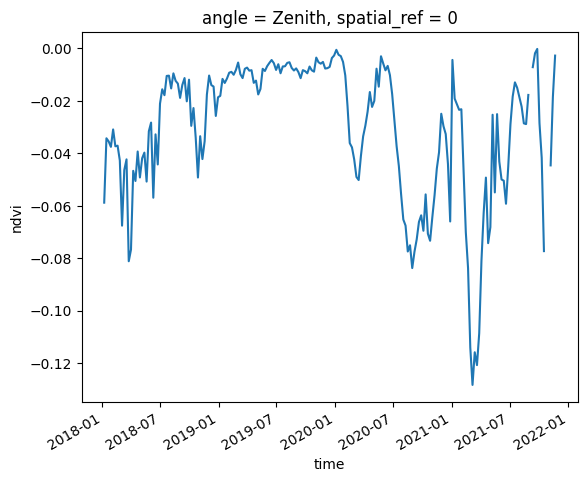

In [50]:
dh_ids_median['ndvi'].plot()

In [13]:
def calculate_distance(data, var):
    """
    Calculate the trend and distance for a given variable.
    
    Parameters:
    - data: xarray.Dataset or pandas.DataFrame containing the time series data.
    - var: str, the variable name to analyze.
    
    Returns:
    - slope: The slope of the trend line.
    - distance: The distance between the lowest and highest points in the time series.
    """
    # Convert xarray.Dataset to pandas.DataFrame if necessary
    if isinstance(data, xr.Dataset):
        df = data.to_dataframe().reset_index()
    elif isinstance(data, pd.DataFrame):
        df = data.copy()
    else:
        raise ValueError("Unsupported data type. Provide xarray.Dataset or pandas.DataFrame.")
    
    # Ensure the variable exists in the data
    if var not in df.columns:
        raise ValueError(f"Variable '{var}' not found in the data.")
    
    # Drop rows with NaN values in the specified variable column
    df = df.dropna(subset=[var])
    
    # Ensure there are enough data points after dropping NaNs
    if len(df) > 1:
        
        # Calculate the distance between the lowest and highest points
        min_value = df[var].min()
        max_value = df[var].max()
        distance = abs(max_value - min_value)

        return distance
    else:
        return np.nan

In [25]:
import pandas as pd

# Define the row labels
row_labels = [
    'drs', 'kdrs', 'kndrs', 'kndvi', 'nbr', 'ndmi', 'ndre', 
    'ndrs', 'ndvi', 'ndwi', 'nirv', 'tcb', 'tcg', 'tcw'
]

# Define the column labels (1 through 20)
column_labels = list(range(1, 21))

# Create the DataFrame with zeros (or any initial value you'd like)
df_ids = pd.DataFrame(0, index=row_labels, columns=column_labels)
df_refdm = pd.DataFrame(0, index=row_labels, columns=column_labels)


In [1]:
import pandas as pd

def combine_ids_refdm_medians(ids_median, refdm_median):
    # Define the row labels
    row_labels = [
        'drs', 'kdrs', 'kndrs', 'kndvi', 'nbr', 'ndmi', 'ndre', 
        'ndrs', 'ndvi', 'ndwi', 'nirv', 'tcb', 'tcg', 'tcw'
    ]

    # Define the column labels (1 through 20)
    column_labels = list(range(1, 21))

    # Create the DataFrame with zeros (or any initial value you'd like)
    df_ids = pd.DataFrame(0, index=row_labels, columns=column_labels)
    df_refdm = pd.DataFrame(0, index=row_labels, columns=column_labels)

    # Assuming df is already created as shown in the previous example
    # ids_median is your list of xarray datasets

    for i, dataset in enumerate(ids_median):
        # Create a dictionary to store distances for the current dataset
        distances = {}

        # Loop over variables in the dataset
        for var in dataset:
            # Check if the variable name does not contain 'anom' or 's2'
            if 'anom' not in var and 's2' not in var:
                # Calculate the distance using your specific logic
                distance = calculate_distance(dataset, var)
                distances[var] = distance

        # Convert the distances dictionary to a Series and align it with the DataFrame's index
        # Note: Ensure the DataFrame `df` has matching row labels (variable names)
        df_ids[i + 1] = pd.Series(distances)


    for i, dataset in enumerate(refdm_median):
        # Create a dictionary to store distances for the current dataset
        distances = {}

        # Loop over variables in the dataset
        for var in dataset:
            # Check if the variable name does not contain 'anom' or 's2'
            if 'anom' not in var and 's2' not in var:
                # Calculate the distance using your specific logic
                distance = calculate_distance(dataset, var)
                distances[var] = distance

        # Convert the distances dictionary to a Series and align it with the DataFrame's index
        # Note: Ensure the DataFrame `df` has matching row labels (variable names)
        df_refdm[i + 1] = pd.Series(distances)

    import pandas as pd

    # Assuming df_ids and df_refdm are your DataFrames

    # Transpose DataFrames and add 'Source' column
    df_ids_melted = df_ids.T
    df_ids_melted['Source'] = 'ids'
    df_refdm_melted = df_refdm.T
    df_refdm_melted['Source'] = 'refdm'

    # Combine DataFrames
    combined_df = pd.concat([df_ids_melted, df_refdm_melted])

    # Remove rows where the 'Source' column has 'Source'
    # First, identify rows where the index is 'Source'
    rows_to_remove = combined_df.index[combined_df.index == 'Source']
    combined_df_cleaned = combined_df.drop(index=rows_to_remove)


    melted_df = combined_df_cleaned.melt(id_vars=['Source'], var_name='Variable', value_name='Value')
    melted_df_sorted = melted_df.sort_values(by=['Source', 'Variable'], ascending=[True, False])
    melted_df_sorted['Variable'] = melted_df_sorted['Variable'].str.upper()
    
    return melted_df_sorted

In [2]:
dd = combine_ids_refdm_medians(ids_median, refdm_median)
dd

NameError: name 'ids_median' is not defined

In [71]:
import pandas as pd

# Assuming df_ids and df_refdm are your DataFrames

# Transpose DataFrames and add 'Source' column
df_ids_melted = df_ids.T
df_ids_melted['Source'] = 'ids'
df_refdm_melted = df_refdm.T
df_refdm_melted['Source'] = 'refdm'

# Combine DataFrames
combined_df = pd.concat([df_ids_melted, df_refdm_melted])

# Remove rows where the 'Source' column has 'Source'
# First, identify rows where the index is 'Source'
rows_to_remove = combined_df.index[combined_df.index == 'Source']
combined_df_cleaned = combined_df.drop(index=rows_to_remove)

# Display the cleaned DataFrame
combined_df_cleaned

melted_df = combined_df_cleaned.melt(id_vars=['Source'], var_name='Variable', value_name='Value')
melted_df_sorted = melted_df.sort_values(by=['Source', 'Variable'], ascending=[True, False])
melted_df_sorted['Variable'] = melted_df_sorted['Variable'].str.upper()
melted_df_sorted

,drs,kdrs,kndrs,kndvi,nbr,ndmi,ndre,ndrs,ndvi,ndwi,nirv,tcb,tcg,tcw,Source
1,0.027201,0.215877,0.107938,0.147955,0.133821,0.112222,0.04599,0.033554,0.119987,0.069313,0.048129,0.039757,0.03685,0.030522,ids
2,0.038137,0.153274,0.076637,0.127434,0.103908,0.090895,0.056317,0.025648,0.084301,0.055492,0.051206,0.084031,0.039806,0.023825,ids
3,0.035529,0.336594,0.168297,0.238681,0.144921,0.160084,0.145748,0.048794,0.14075,0.082143,0.083805,0.053349,0.065794,0.053886,ids
4,0.033787,0.528107,0.264054,0.320541,0.180226,0.151705,0.077956,0.05167,0.102032,0.09217,0.066404,0.088154,0.054213,0.045038,ids
5,0.023152,0.1701,0.08505,0.131232,0.260055,0.159169,0.053467,0.03595,0.089717,0.065694,0.047797,0.054018,0.044544,0.042092,ids
6,0.035306,0.21625,0.108125,0.169696,0.181688,0.177707,0.071044,0.053019,0.156671,0.073001,0.066511,0.051238,0.049928,0.04233,ids
7,0.037326,0.274292,0.137146,0.144939,0.185897,0.15992,0.07822,0.045039,0.152832,0.050607,0.065304,0.054033,0.047979,0.045391,ids
8,0.016502,0.165694,0.082847,0.139786,0.118621,0.097248,0.033672,0.022298,0.10038,0.071633,0.033458,0.028609,0.026017,0.027684,ids
9,0.01165,0.018384,0.009192,0.018011,0.183013,0.149099,0.085579,0.017145,0.177633,0.085271,0.102307,0.058729,0.081617,0.021215,ids
10,0.026042,0.232267,0.116134,0.191477,0.209901,0.178038,0.065956,0.039825,0.091699,0.066214,0.064079,0.037413,0.049958,0.038335,ids


In [98]:
# Assuming combined_df_cleaned is the DataFrame you have
# Ensure that 'Source' column is included for grouping
# Reshape the DataFrame for plotting
melted_df = combined_df_cleaned.melt(id_vars=['Source'], var_name='Variable', value_name='Value')
melted_df_sorted = melted_df.sort_values(by=['Source', 'Variable'], ascending=[True, False])
melted_df_sorted['Variable'] = melted_df_sorted['Variable'].str.upper()
melted_df_sorted

,Source,Variable,Value
520,ids,TCW,0.030522
521,ids,TCW,0.023825
522,ids,TCW,0.053886
523,ids,TCW,0.045038
524,ids,TCW,0.042092
...,...,...,...
35,refdm,DRS,NaN
36,refdm,DRS,0.045317
37,refdm,DRS,0.027499
38,refdm,DRS,0.112487


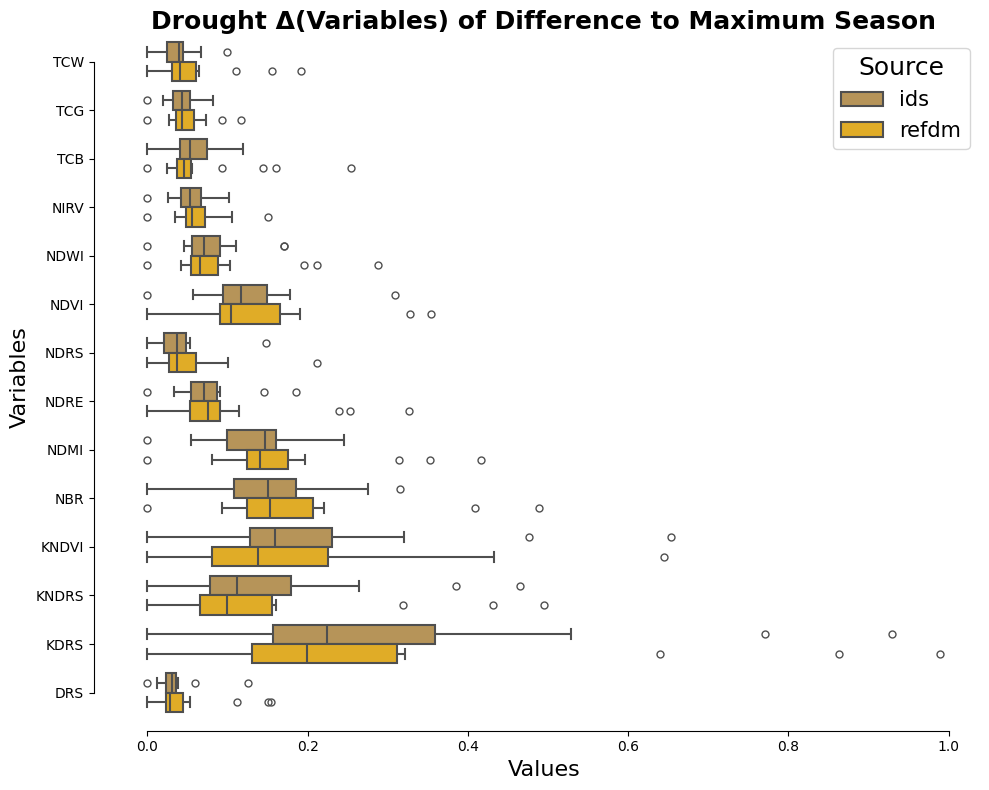

In [99]:
# Define the custom palette
custom_palette = {
    'ids': '#C59849',  
    'refdm': '#FFBA08'  # '#F7DB6D'
}

# Set up the matplotlib figure and axis
plt.figure(figsize=(10, 8))

# Create the boxplot with the custom palette
boxplot = sns.boxplot(
    data=melted_df_sorted,
    x='Value',
    y='Variable',
    hue='Source',
    orient='h',
    palette=custom_palette,
    linewidth=1.5,  # Thicker box outline
    fliersize=5    # Size of outliers
)

# Adjust the median line thickness
for artist in boxplot.artists:
    artist.set_edgecolor('black')  # Color for box outlines
    artist.set_linewidth(2.5)      # Thickness of box outlines

# Adjust the median line thickness and color
for line in boxplot.lines:
    if 'median' in line.get_label():
        line.set_linewidth(2.5)  # Thicker median lines
        line.set_color('black')  # Color for median lines

# Capitalize the legend labels and make them larger
plt.legend(title='Source', title_fontsize='20', fontsize='18', loc='upper right', frameon=True, framealpha=0.8)

# Capitalize the Variable labels and increase their size
plt.yticks(fontsize=18, fontweight='bold', rotation=0)
plt.xticks(fontsize=18)

# Set the title and labels
plt.title('Drought Δ(Variables) of Difference to Maximum Season', fontsize=18, fontweight='bold')
plt.xlabel('Values', fontsize=16)
plt.ylabel('Variables', fontsize=16)

sns.despine(offset=10, trim=True)
# Improve layout for better readability
plt.tight_layout()

# Show the plot
plt.show()

In [55]:
# Save the DataFrame as a CSV file
results_df.to_csv("/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/drougth_distance_results.csv", index=False)

<Figure size 1200x1000 with 0 Axes>

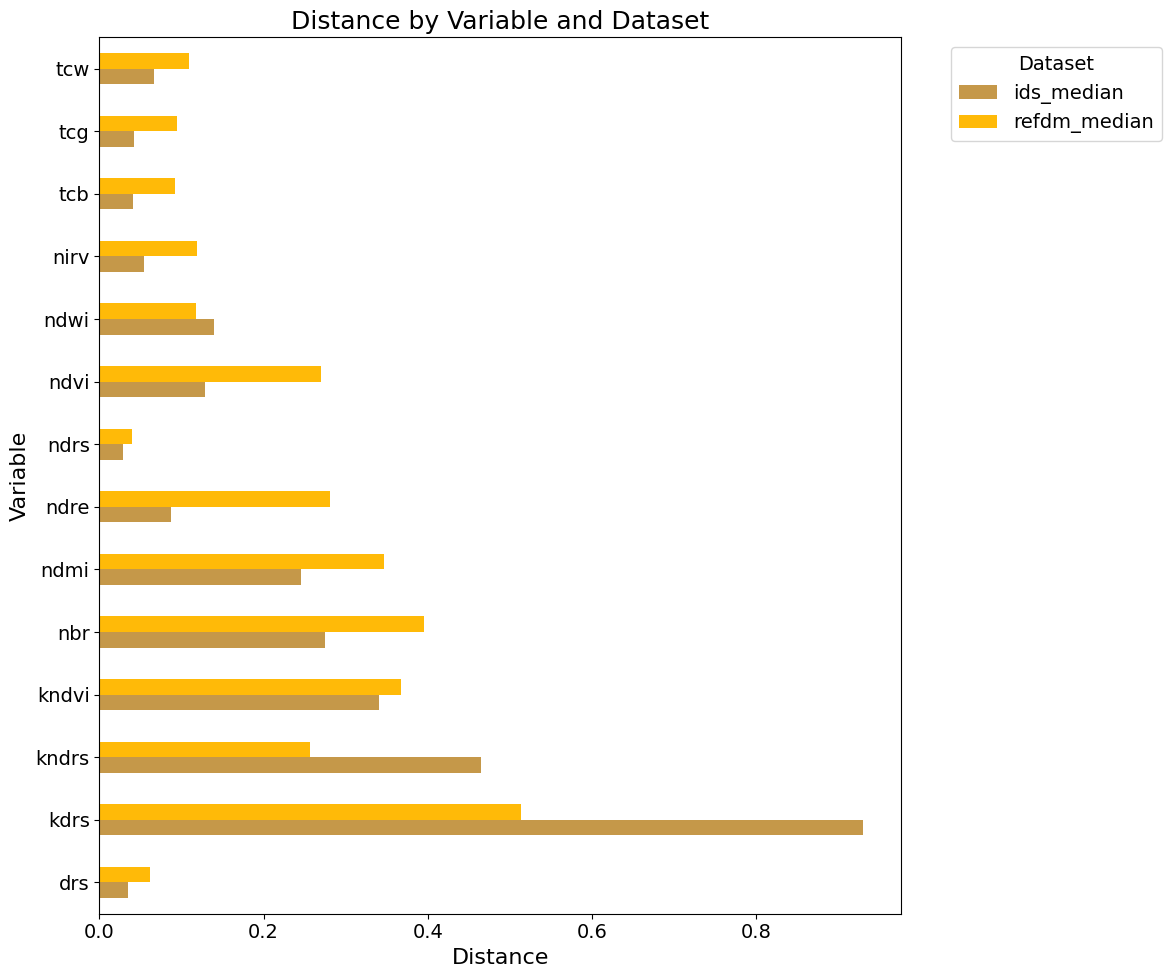

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set font sizes for various components
plt.rcParams.update({
    'font.size': 14,           # Global font size
    'axes.titlesize': 18,      # Title font size
    'axes.labelsize': 16,      # X and Y label font size
    'xtick.labelsize': 14,     # X tick label font size
    'ytick.labelsize': 14,     # Y tick label font size
})

# Filter the DataFrame to include only 'refdm_median' and 'ids_median'
filtered_df = results_df[results_df['Dataset'].isin(['refdm_median', 'ids_median'])]

# Pivot the filtered DataFrame
pivot_df = filtered_df.pivot(index='Variable', columns='Dataset', values='Distance')

# Define a custom color palette with shades of orange and brown
custom_palette = {
    'ids_median': '#C59849',  
    'refdm_median': '#FFBA08'  #F7DB6D
}

# Plotting
plt.figure(figsize=(12, 10))
ax = pivot_df.plot(kind='barh', figsize=(12, 10), color=[custom_palette.get(x, '#333333') for x in pivot_df.columns])

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Variable')
plt.title('Distance by Variable and Dataset')
plt.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:

def plot_distance_and_slope_per_disturbancetype_ids_refdm_diff(quantiles, figure_path):
    # Create subplots for slopes and distances
    fig, axs = plt.subplots(2, 3, figsize=(30, 15), constrained_layout=True)

    # Variables for x-axis positioning
    x = np.arange(len(quantiles))

    # Define colors for each percentile
    colors = ['orange', 'blue']

    # Plot Slope Medians for IDS
    axs[0, 0].bar(x, quantiles['Slope_IDS_Median'], color=colors[0])
    axs[0, 0].set_title('Slope Medians for IDS')
    axs[0, 0].set_ylabel('Slope Median')
    axs[0, 0].set_xticks(x)
    axs[0, 0].set_xticklabels(quantiles['Variable'], rotation=90)

    # Highlight max slope median difference for IDS
    max_slope_median_ids = quantiles['Slope_IDS_Median'].max()
    axs[0, 0].axhline(max_slope_median_ids, color='red', linestyle='--', label=f'Max Median IDS ({max_slope_median_ids})')
    axs[0, 0].legend()

    # Plot Slope Medians for REFDM
    axs[0, 1].bar(x, quantiles['Slope_REFDM_Median'], color=colors[1])
    axs[0, 1].set_title('Slope Medians for REFDM')
    axs[0, 1].set_ylabel('Slope Median')
    axs[0, 1].set_xticks(x)
    axs[0, 1].set_xticklabels(quantiles['Variable'], rotation=90)

    # Highlight max slope median difference for REFDM
    max_slope_median_refdm = quantiles['Slope_REFDM_Median'].max()
    axs[0, 1].axhline(max_slope_median_refdm, color='red', linestyle='--', label=f'Max Median REFDM ({max_slope_median_refdm})')
    axs[0, 1].legend()

    # Plot Slope Differences
    axs[0, 2].bar(x, quantiles['Slope_Median_Diff'], color=colors[0])
    axs[0, 2].set_title('Slope Differences between IDS and REFDM')
    axs[0, 2].set_ylabel('Absolute Difference')
    axs[0, 2].set_xticks(x)
    axs[0, 2].set_xticklabels(quantiles['Variable'], rotation=90)

    # Highlight max slope median difference
    max_slope_diff = quantiles['Slope_Median_Diff'].max()
    max_slope_diff_var = quantiles.loc[quantiles['Slope_Median_Diff'].idxmax(), 'Variable']
    axs[0, 2].axhline(max_slope_diff, color='red', linestyle='--', label=f'Max Median Diff ({max_slope_diff_var})')
    axs[0, 2].legend()

    # Plot Distance Medians for IDS
    axs[1, 0].bar(x, quantiles['Distance_IDS_Median'], color=colors[0])
    axs[1, 0].set_title('Distance Medians for IDS')
    axs[1, 0].set_ylabel('Distance Median')
    axs[1, 0].set_xticks(x)
    axs[1, 0].set_xticklabels(quantiles['Variable'], rotation=90)

    # Highlight max distance median difference for IDS
    max_distance_median_ids = quantiles['Distance_IDS_Median'].max()
    axs[1, 0].axhline(max_distance_median_ids, color='red', linestyle='--', label=f'Max Median IDS ({max_distance_median_ids})')
    axs[1, 0].legend()

    # Plot Distance Medians for REFDM
    axs[1, 1].bar(x, quantiles['Distance_REFDM_Median'], color=colors[1])
    axs[1, 1].set_title('Distance Medians for REFDM')
    axs[1, 1].set_ylabel('Distance Median')
    axs[1, 1].set_xticks(x)
    axs[1, 1].set_xticklabels(quantiles['Variable'], rotation=90)

    # Highlight max distance median difference for REFDM
    max_distance_median_refdm = quantiles['Distance_REFDM_Median'].max()
    axs[1, 1].axhline(max_distance_median_refdm, color='red', linestyle='--', label=f'Max Median REFDM ({max_distance_median_refdm})')
    axs[1, 1].legend()

    # Plot Distance Differences
    axs[1, 2].bar(x, quantiles['Distance_Median_Diff'], color=colors[0])
    axs[1, 2].set_title('Distance Differences between IDS and REFDM')
    axs[1, 2].set_ylabel('Absolute Difference')
    axs[1, 2].set_xticks(x)
    axs[1, 2].set_xticklabels(quantiles['Variable'], rotation=90)

    # Highlight max distance median difference
    max_distance_diff = quantiles['Distance_Median_Diff'].max()
    max_distance_diff_var = quantiles.loc[quantiles['Distance_Median_Diff'].idxmax(), 'Variable']
    axs[1, 2].axhline(max_distance_diff, color='red', linestyle='--', label=f'Max Median Diff ({max_distance_diff_var})')
    axs[1, 2].legend()

    # Adjust layout
    plt.tight_layout()

    # Save the plot
    plt.savefig(figure_path)
    plt.show()



## Calculate Max, Min, Mean season and diff to that!!

In [23]:
# calculate the max for ids and refdm --- BUT how do I calculate the baseline for ids and refdm? i need to take the same reference to distract from there
#difference_mean, perfect_saision_mean, normal_timeseries_mean = calculatePerfectSaison(clipped_data_ids, start_year, method='mean')
difference_max, perfect_saision_max, normal_timeseries_max = calculatePerfectSaison(clipped_data_ids, start_year, method='max')
#difference_min, perfect_saision_min, normal_timeseries_min = calculatePerfectSaison(clipped_data_ids, start_year, method='min')

# extract for ids and refdm 25,50,75 percentiles for each vegitation index and store it in seperate dataframes....
median_diff = difference_max.median(dim=['x', 'y'])
q25_diff = difference_max.quantile(0.25, dim=['x', 'y'])
q75_diff = difference_max.quantile(0.75, dim=['x', 'y'])
# update datafraame (mean) in every loop

# result: 3 dataframes a) 25% b) median c) 75%

Starting the calculation...
Resampling the original dataset...
Calculating max values...


/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/lib/python3.8/site-packages/xarray/core/accessor_dt.py:408: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  warnings.warn(


Concatenating yearly datasets...
Smoothing datasets...
Calculating differences...
Calculation completed.


/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


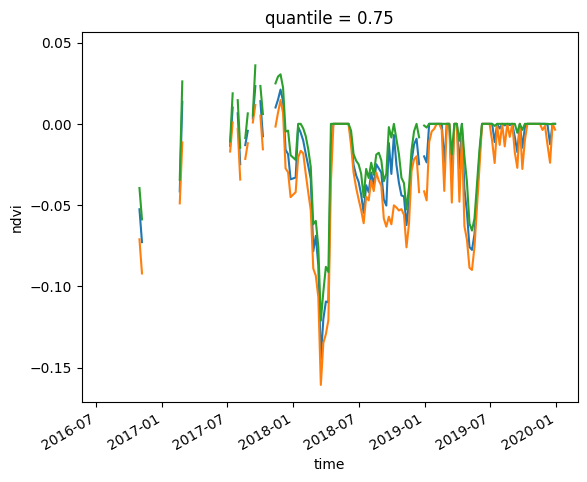

In [24]:
median_diff['ndvi'].plot()
q25_diff['ndvi'].plot()
q75_diff['ndvi'].plot()

# Boxplot for all disturbances

In [11]:
dist = 'drought'
drought =  pd.read_csv(f"/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/distance/{dist}/combined_{dist}_medians.csv")
drought = drought.drop(columns=['Unnamed: 0'])

dist = 'wind'
wind =  pd.read_csv(f"/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/distance/{dist}/combined_{dist}_medians.csv")
wind = wind.drop(columns=['Unnamed: 0'])

dist = 'fire'
fire =  pd.read_csv(f"/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/distance/{dist}/combined_{dist}_medians.csv")
fire = fire.drop(columns=['Unnamed: 0'])

dist = 'defoliators'
defoliators =  pd.read_csv(f"/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/distance/{dist}/combined_{dist}_medians.csv")
defoliators = defoliators.drop(columns=['Unnamed: 0'])

dist = 'bark_beetle'
bark_beetle =  pd.read_csv(f"/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/distance/{dist}/combined_{dist}_medians.csv")
bark_beetle = bark_beetle.drop(columns=['Unnamed: 0'])


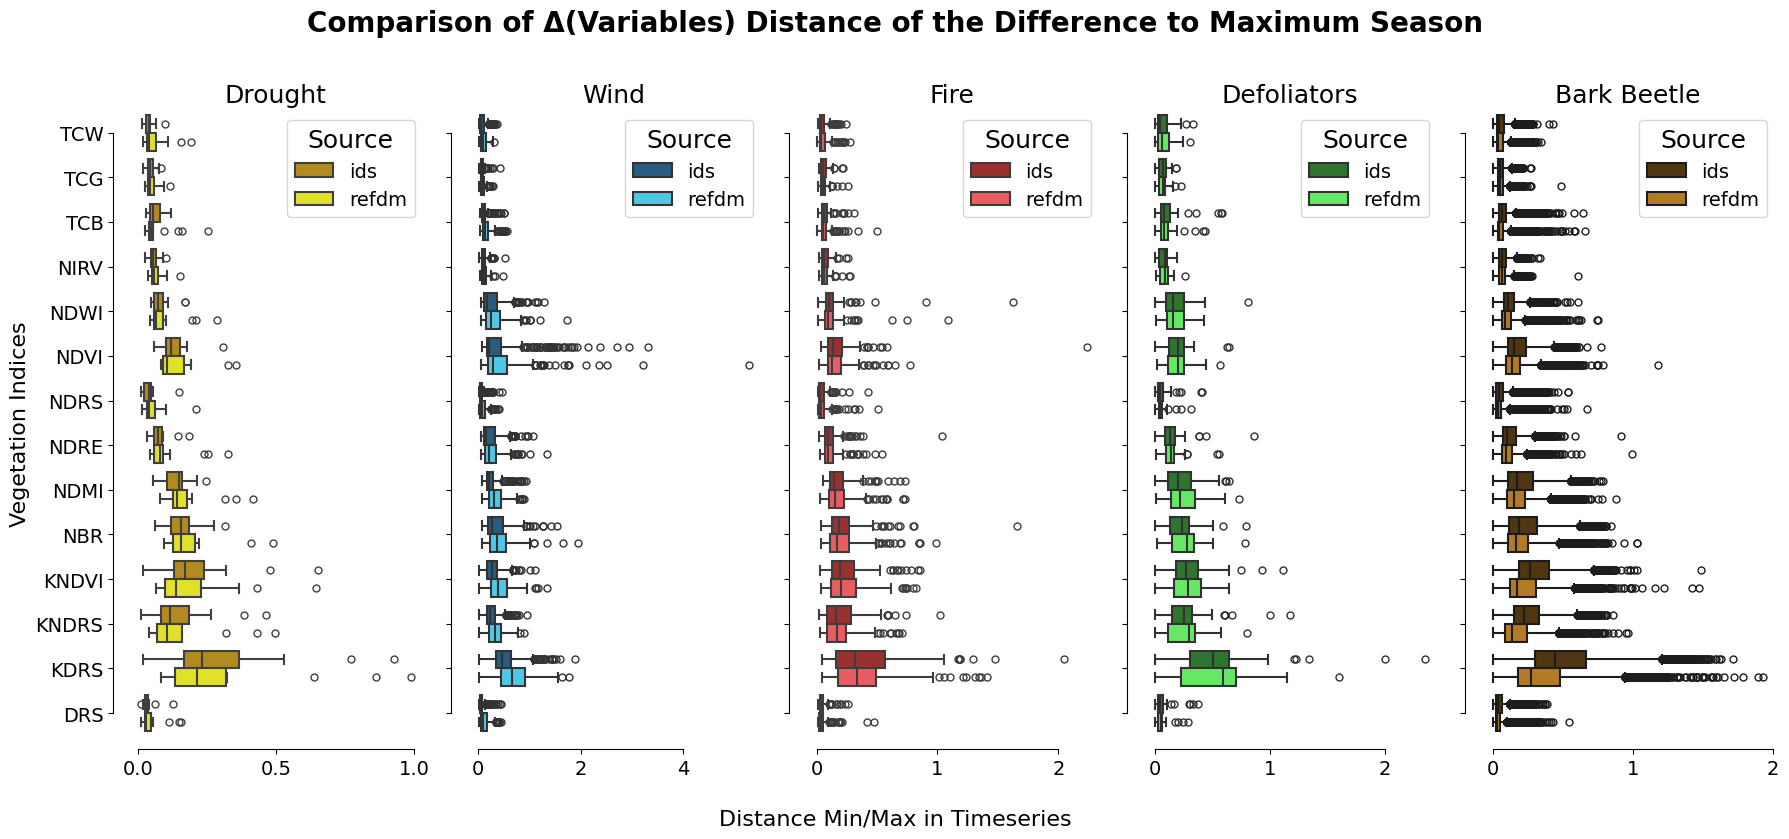

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load your datasets
disturbances = {
    'Drought': drought,
    'Wind': wind,
    'Fire': fire,
    'Defoliators': defoliators,
    'Bark Beetle': bark_beetle
}

# Define the custom colors for each disturbance
custom_colors = {
    'Drought': '#FFBA08',   # yellow
    'Wind': '#1f77b4',      # blue
    'Fire': '#d62728',      # red
    'Defoliators': '#2ca02c',  # green
    'Bark Beetle': '#714709'  # brown
}

# Function to darken a color
def darken_color(color, amount=1.2):
    c = mcolors.to_rgb(color)
    return mcolors.to_hex([max(min(c[i] * amount, 1.0), 0.0) for i in range(3)])

# Set up the matplotlib figure and axis
fig, axes = plt.subplots(1, len(disturbances), figsize=(18, 8), sharey=True)

# Ensure axes is iterable
if len(disturbances) == 1:
    axes = [axes]

# Plot each disturbance in its subplot
for ax, (disturbance_name, df) in zip(axes, disturbances.items()):
    # Define custom palette for ids and refdm with darkened colors
    custom_palette = {
        'ids': darken_color(custom_colors[disturbance_name], 0.8),  
        'refdm': darken_color(custom_colors[disturbance_name], 1.8)
    }

    # Create the boxplot with the custom palette
    boxplot = sns.boxplot(
        data=df,
        x='Value',
        y='Variable',
        hue='Source',
        orient='h',
        palette=custom_palette,
        linewidth=1.5,
        fliersize=5,
        ax=ax
    )
    # Set x-axis to log scale
    #ax.set_xscale('log')

    # Adjust the median line thickness
    for artist in boxplot.artists:
        artist.set_edgecolor('black')
        artist.set_linewidth(2.5)

    for line in boxplot.lines:
        if 'median' in line.get_label():
            line.set_linewidth(2.5)
            line.set_color('black')

    # Customize the subplot
    ax.set_title(f'{disturbance_name}', fontsize=18)
    ax.set_ylabel('Vegetation Indices', fontsize=16)
    ax.legend(title='Source', title_fontsize='18', fontsize='14', loc='upper right', frameon=True, framealpha=0.8)

    # Capitalize the Variable labels and increase their size
    ax.tick_params(axis='y', labelsize=14, labelrotation=0)
    ax.tick_params(axis='x', labelsize=14)
    ax.set_xlabel('')

# Add a single x-label for the entire figure
fig.text(0.5, -0.04, 'Distance Min/Max in Timeseries', ha='center', fontsize=16)

# Add a super title above all the subplots
fig.suptitle('Comparison of Δ(Variables) Distance of the Difference to Maximum Season', fontsize=20, fontweight='bold')

sns.despine(offset=10, trim=True)

# Improve layout for better readability
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make space for the super title

# Save the figure
plt.savefig('/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/figures/disturbance_diff_max_distance_comparison_plot.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


In [44]:
def format_label(label):
    return ' '.join(word.capitalize() for word in label.split('_'))

In [46]:
def plot_singular_disturbance_boxplot(disturbance, disturbance_name, colors, path):

    # Set up the matplotlib figure and axis
    plt.figure(figsize=(10, 8))

    # Create the boxplot with the custom palette
    boxplot = sns.boxplot(
        data=disturbance,
        x='Value',
        y='Variable',
        hue='Source',
        orient='h',
        palette=colors,
        linewidth=1.5,  # Thicker box outline
        fliersize=5    # Size of outliers
    )

    # Adjust the median line thickness
    for artist in boxplot.artists:
        artist.set_edgecolor('black')  # Color for box outlines
        artist.set_linewidth(2.5)      # Thickness of box outlines

    # Adjust the median line thickness and color
    for line in boxplot.lines:
        if 'median' in line.get_label():
            line.set_linewidth(2.5)  # Thicker median lines
            line.set_color('black')  # Color for median lines

    # Capitalize the legend labels and make them larger
    plt.legend(title='Source', title_fontsize='20', fontsize='18', loc='upper right', frameon=True, framealpha=0.8)

    # Capitalize the Variable labels and increase their size
    plt.yticks(fontsize=18, fontweight='bold', rotation=0)
    plt.xticks(fontsize=18)

    # Set the title and labels
    plt.title(f'{format_label(disturbance_name)} Δ(Variables) of Difference to Maximum Season', fontsize=18, fontweight='bold')
    plt.xlabel('Values', fontsize=16)
    plt.ylabel('Variables', fontsize=16)

    sns.despine(offset=10, trim=True)
    # Improve layout for better readability
    plt.tight_layout()
    # Save the figure
    plt.savefig(path, dpi=300, bbox_inches='tight')

    # Show the plot
    plt.show()

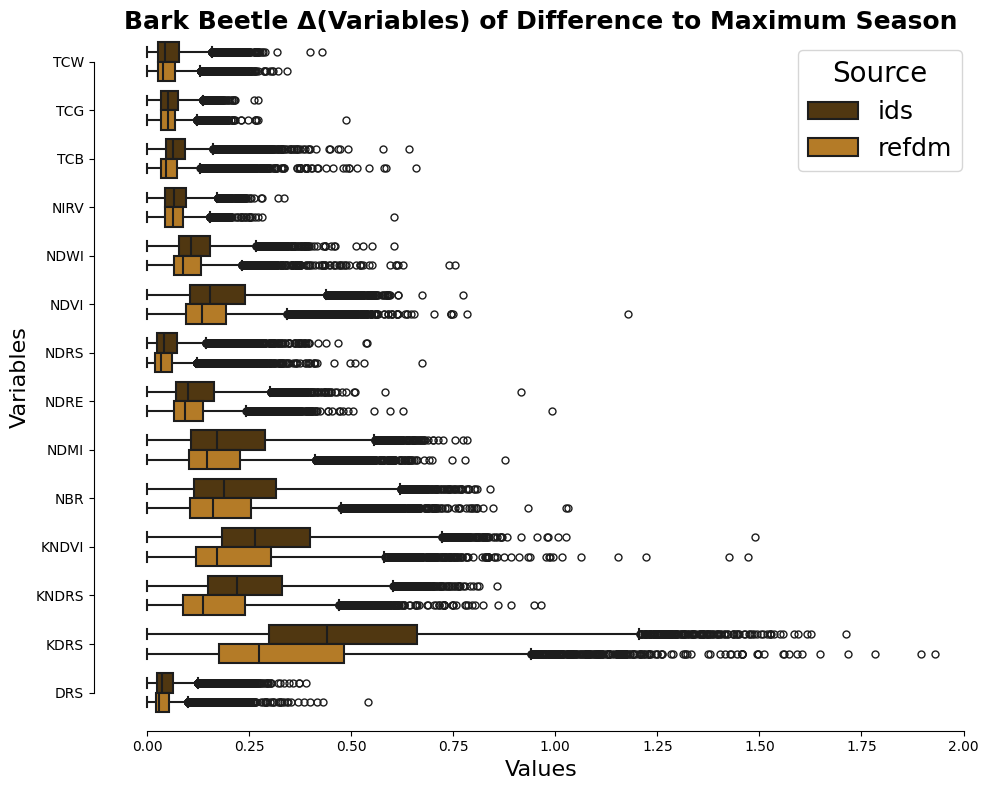

In [50]:
disturbance_name = 'bark_beetle'
custom_colors = {
    'wind': '#1f77b4',      # tab:blue
    'fire': '#d62728',      # tab:red
    'defoliators': '#2ca02c',  # tab:green
    'drought': '#FFBA08', # tab:yellow
    'bark_beetle': '#714709'  # tab:brown
}
# Function to darken a color
def darken_color(color, amount=1.2):
    c = mcolors.to_rgb(color)
    return mcolors.to_hex([max(min(c[i] * amount, 1.0), 0.0) for i in range(3)])

custom_palette = {
    'ids': darken_color(custom_colors[disturbance_name], 0.8),  
    'refdm': darken_color(custom_colors[disturbance_name], 1.8)
}

plot_singular_disturbance_boxplot(bark_beetle, disturbance_name, custom_palette, path=f"/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/figures/disturbance_diff_max_distance_{disturbance_name}_plot.png")